<a href="https://colab.research.google.com/github/wandersonmaia-analyst/solucao_monitoramento_fauna/blob/main/analise_fauna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/wandersonmaia-analyst/fast-track-ia-t1.git

Cloning into 'fast-track-ia-t1'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 31 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 199.59 KiB | 3.99 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Configurações visuais dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 🛠️ BÔNUS 1 & SETUP: Carregamento, Mapeamento e Limpeza de Dados

In [24]:
# Caminho completo do arquivo JSON
caminho_arquivo = 'fast-track-ia-t1/checkpoints/monitoramento-fauna/dataset.json'

# Carrega os dados em um DataFrame
df = pd.read_json(caminho_arquivo)

In [25]:
# Exibe as primeiras linhas para verificar se deu certo
df.head()

,id_registro,id_camera,data_hora_inicio,duracao_segundos,especie,grupo,individuos,temperatura_c,umidade_pct
0,1,CAM01,2026-05-01 00:04:00,25,Ema,Ave,3,19.3 °C,81.5%
1,2,CAM08,2026-05-01 00:18:00,9,Rã-manteiga,Anfíbio,3,16.6 °C,88.8%
2,3,CAM08,2026-05-01 00:32:00,6,Tatu-canastra,Mamífero,1,16.5 °C,96.3%
3,4,CAM12,2026-05-01 00:37:00,13,Rã-manteiga,Anfíbio,2,19.2 °C,92.1%
4,5,CAM03,2026-05-01 00:39:00,25,Tamanduá-bandeira,Mamífero,1,20.5 °C,82.6%


In [28]:
# Mapeamento oficial das áreas do parque conforme o enunciado
mapa_ambientes = {
    'CAM01': 'Cerrado Aberto', 'CAM02': 'Cerrado Aberto', 'CAM03': 'Cerrado Aberto', 'CAM04': 'Cerrado Aberto',
    'CAM05': 'Mata de Galeria', 'CAM06': 'Mata de Galeria', 'CAM07': 'Mata de Galeria', 'CAM08': 'Mata de Galeria',
    'CAM09': 'Veredas e Áreas Úmidas', 'CAM10': 'Veredas e Áreas Úmidas', 'CAM11': 'Veredas e Áreas Úmidas', 'CAM12': 'Veredas e Áreas Úmidas'
}
df['ambiente'] = df['id_camera'].map(mapa_ambientes)

In [30]:
# 1. Informações gerais do dataset (verificar tipos e nulos)
print("--- Informações Gerais ---")
print(df.info())

--- Informações Gerais ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id_registro       5000 non-null   int64 
 1   id_camera         5000 non-null   object
 2   data_hora_inicio  5000 non-null   object
 3   duracao_segundos  5000 non-null   int64 
 4   especie           5000 non-null   object
 5   grupo             5000 non-null   object
 6   individuos        5000 non-null   int64 
 7   temperatura_c     4753 non-null   object
 8   umidade_pct       4825 non-null   object
 9   ambiente          5000 non-null   object
dtypes: int64(3), object(7)
memory usage: 390.8+ KB
None


In [32]:
# 1. Limpeza da coluna de Temperatura
if df['temperatura_c'].dtype == 'object':
    # Remove o sufixo " °C"
    df['temperatura_c'] = df['temperatura_c'].astype(str).str.replace(' °C', '', regex=False)
    # Substitui strings 'None', 'nan' ou vazias por NaN real do NumPy
    df['temperatura_c'] = df['temperatura_c'].replace(['None', 'nan', '', 'NaN'], np.nan)
    # Converte para float com segurança (erros='coerce' transforma qualquer falha restante em NaN)
    df['temperatura_c'] = pd.to_numeric(df['temperatura_c'], errors='coerce')

In [33]:
# 2. Limpeza da coluna de Umidade
if df['umidade_pct'].dtype == 'object':
    # Remove o sufixo "%"
    df['umidade_pct'] = df['umidade_pct'].astype(str).str.replace('%', '', regex=False)
    # Substitui strings inválidas por NaN real
    df['umidade_pct'] = df['umidade_pct'].replace(['None', 'nan', '', 'NaN'], np.nan)
    # Converte para float com segurança
    df['umidade_pct'] = pd.to_numeric(df['umidade_pct'], errors='coerce')

In [34]:
# 3. Tratamento de valores nulos encontrados (Tratativa do Bônus 1)
# Aqui optamos por preencher com a mediana da respectiva câmera para não perder o registro do animal
df['temperatura_c'] = df.groupby('id_camera')['temperatura_c'].transform(lambda x: x.fillna(x.median()))
df['umidade_pct'] = df.groupby('id_camera')['umidade_pct'].transform(lambda x: x.fillna(x.median()))

In [35]:
# 4. Tratamento temporal
df['data_hora_inicio'] = pd.to_datetime(df['data_hora_inicio'])
df['hora'] = df['data_hora_inicio'].dt.hour

def classificar_periodo(hora):
    if 5 <= hora < 12: return 'Manhã'
    elif 12 <= hora < 18: return 'Tarde'
    else: return 'Noite/Madrugada'

df['periodo_dia'] = df['hora'].apply(classificar_periodo)

In [36]:
print("✅ Dados limpos, strings 'None' tratadas e valores nulos corrigidos com sucesso!")
df.head()

✅ Dados limpos, strings 'None' tratadas e valores nulos corrigidos com sucesso!


,id_registro,id_camera,data_hora_inicio,duracao_segundos,especie,grupo,individuos,temperatura_c,umidade_pct,ambiente,hora,periodo_dia
0,1,CAM01,2026-05-01 00:04:00,25,Ema,Ave,3,19.3,81.5,Cerrado Aberto,0,Noite/Madrugada
1,2,CAM08,2026-05-01 00:18:00,9,Rã-manteiga,Anfíbio,3,16.6,88.8,Mata de Galeria,0,Noite/Madrugada
2,3,CAM08,2026-05-01 00:32:00,6,Tatu-canastra,Mamífero,1,16.5,96.3,Mata de Galeria,0,Noite/Madrugada
3,4,CAM12,2026-05-01 00:37:00,13,Rã-manteiga,Anfíbio,2,19.2,92.1,Veredas e Áreas Úmidas,0,Noite/Madrugada
4,5,CAM03,2026-05-01 00:39:00,25,Tamanduá-bandeira,Mamífero,1,20.5,82.6,Cerrado Aberto,0,Noite/Madrugada


Passo 1: Análise Inicial e Limpeza dos Dados

In [6]:
# 1. Verificar se existem linhas completamente duplicadas
print("\nLinhas duplicadas:", df.duplicated().sum())


Linhas duplicadas: 0


In [37]:
# 2. Verificar se os nomes das espécies estão corretos e padronizados
print("\n--- Espécies encontradas no dataset ---")
print(df['especie'].unique())


--- Espécies encontradas no dataset ---
['Ema' 'Rã-manteiga' 'Tatu-canastra' 'Tamanduá-bandeira' 'Sapo-cururu'
 'Quati' 'Perereca-verde' 'Capivara' 'Veado-campeiro' 'Lobo-guará'
 'Seriema' 'Onça-pintada' 'Cervo-do-pantanal']


In [38]:
# 3. Verificar estatísticas básicas para caçar anomalias (ex: temperaturas absurdas, valores negativos)
print("\n--- Resumo Estatístico ---")
print(df[['duracao_segundos', 'individuos', 'temperatura_c', 'umidade_pct']].describe())


--- Resumo Estatístico ---
       duracao_segundos  individuos  temperatura_c  umidade_pct
count       5000.000000  5000.00000    5000.000000  5000.000000
mean          26.706000     2.86540      23.050320    77.012880
std           17.760401     1.99371       4.174419    12.465893
min            3.000000     1.00000      12.300000    44.300000
25%           14.000000     1.00000      19.500000    67.400000
50%           23.000000     2.00000      23.300000    77.400000
75%           36.000000     4.00000      26.400000    86.700000
max          167.000000    14.00000      34.100000    99.000000


## Desafio 1: Animais solitários ou em grupo? (Foco: Capivara)



In [39]:
df_capivara = df[df['especie'].str.lower() == 'capivara']

In [40]:
media_ind = df_capivara['individuos'].mean()
solitarios = df_capivara[df_capivara['individuos'] == 1].shape[0]
em_grupo = df_capivara[df_capivara['individuos'] > 1].shape[0]

In [41]:
print(f"Número médio de indivíduos por registro de Capivara: {media_ind:.2f}")
print(f"Registros solitários: {solitarios} | Registros em grupo: {em_grupo}")

Número médio de indivíduos por registro de Capivara: 5.95
Registros solitários: 6 | Registros em grupo: 725


/tmp/ipykernel_7242/2306960688.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_capivara, x='individuos', palette='viridis')


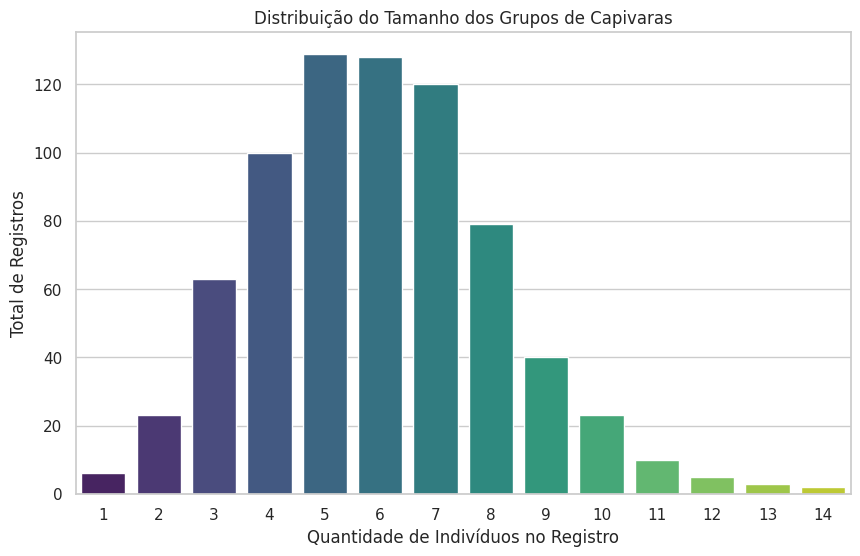

In [42]:
# Gráfico para evidência
sns.countplot(data=df_capivara, x='individuos', palette='viridis')
plt.title('Distribuição do Tamanho dos Grupos de Capivaras')
plt.xlabel('Quantidade de Indivíduos no Registro')
plt.ylabel('Total de Registros')
plt.show()

##Desafio 2: Quando a fauna está mais activa?

In [43]:
# 1. Visão geral por período
print(df['periodo_dia'].value_counts())

periodo_dia
Noite/Madrugada    2021
Manhã              1662
Tarde              1317
Name: count, dtype: int64


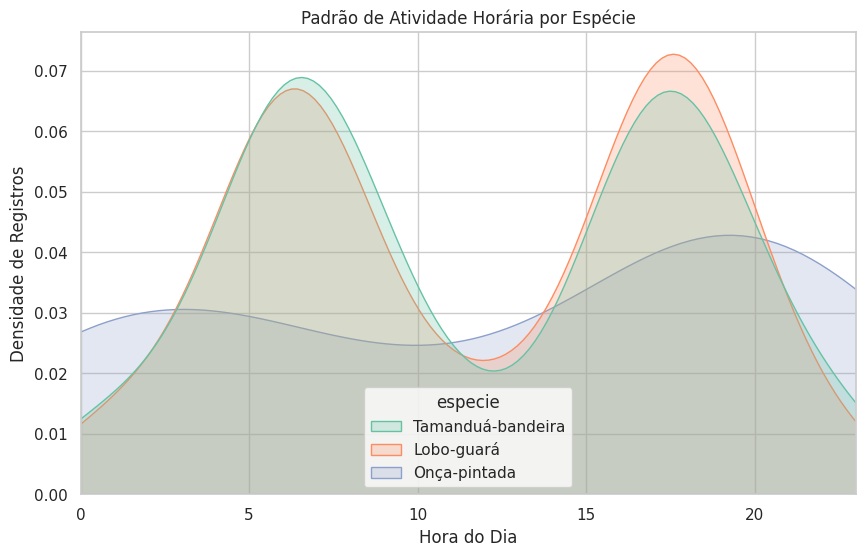

In [44]:
# 2. Comparando 3 espécies específicas (Exemplo: Lobo-guará, Tamanduá-bandeira e Onça-pintada)
especies_selecionadas = ['Lobo-guará', 'Tamanduá-bandeira', 'Onça-pintada']
df_tres_esp = df[df['especie'].isin(especies_selecionadas)]

sns.kdeplot(data=df_tres_esp, x='hora', hue='especie', common_norm=False, fill=True, palette='Set2')
plt.title('Padrão de Atividade Horária por Espécie')
plt.xlabel('Hora do Dia')
plt.ylabel('Densidade de Registros')
plt.xlim(0, 23)
plt.show()